# Appendix II: Final methodology for arc clustering

A brief overview of how I ended up with my finalised methodology.

In [1]:
import sys
!{sys.executable} -m pip install --quiet seaborn scipy scikit-learn numpy pandas matplotlib py_pcha umap-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Section 1: Load and validate
I load the 20-point emotional arc vectors produced by the arc generation pipeline. Each row is one film; columns w01–w20 are mean-centred, z-scored RoBERTa sentiment scores sampled at 20 equally-spaced narrative positions.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Plot styling — match case-studies notebook
plt.rcParams.update({
    'font.family'      : 'Baskerville',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'figure.titlesize'   : 14,
    'figure.titleweight' : 'bold',
})


# Paths
ARC_CSV    = "../data/processed/emotional_arcs.csv"
OUTPUT_DIR = "../docs/thesis-outputs/"

ARC_COLS = [f"w{str(i).zfill(2)}" for i in range(1, 21)]  # w01 … w20
x_pos    = np.linspace(0, 1, 20)

# Load
df = pd.read_csv(ARC_CSV)

def year_to_decade(year):
    if   1980 <= year <= 1989: return "1980s"
    elif 1990 <= year <= 1999: return "1990s"
    elif 2000 <= year <= 2009: return "2000s"
    elif 2010 <= year <= 2019: return "2010s"
    elif 2020 <= year <= 2025: return "2020s"
    else: return "Other"

df["decade"]        = df["year"].apply(year_to_decade)
df["primary_genre"] = df["genre"].str.split("|").str[0]

print(f"Corpus: {df.shape[0]} films, {len(ARC_COLS)} arc points each")
print(f"Missing values in arc vectors: {df[ARC_COLS].isnull().sum().sum()}")
print("\nDecade distribution:")
for decade, count in df["decade"].value_counts().sort_index().items():
    print(f"  {decade}: {count:4d}  ({count/len(df)*100:.1f}%)")

Corpus: 1627 films, 20 arc points each
Missing values in arc vectors: 0

Decade distribution:
  1980s:  214  (13.2%)
  1990s:  287  (17.6%)
  2000s:  310  (19.1%)
  2010s:  569  (35.0%)
  2020s:  247  (15.2%)


Not missing anything. Fantastic. Now a quick sanity check for me:

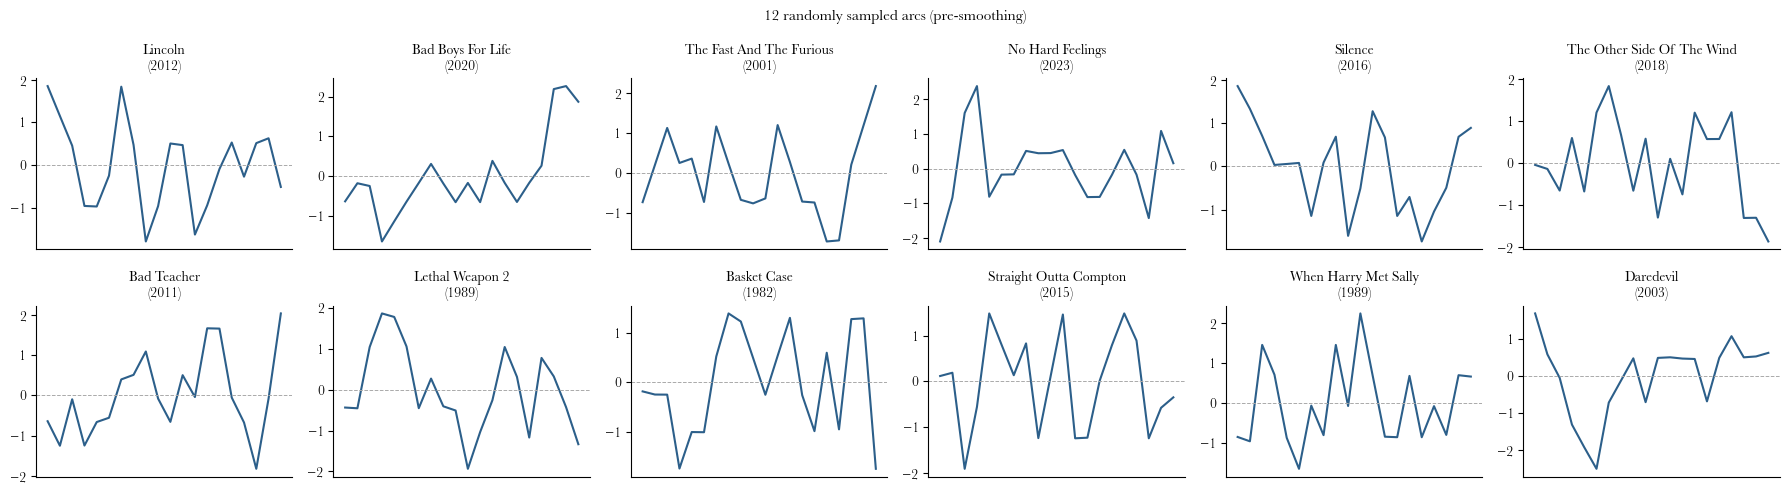

In [3]:
# 12 randomly sampled arcs for a visual sanity check
rng        = np.random.default_rng(seed=42)
sample_idx = rng.choice(len(df), size=12, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(18, 5))
for ax, idx in zip(axes.flatten(), sample_idx):
    ax.plot(x_pos, df.iloc[idx][ARC_COLS].values.astype(float),
            color="#2C5F8A", linewidth=1.5)
    ax.axhline(0, color="#AAAAAA", linewidth=0.7, linestyle="--")
    ax.set_title(f"{df.iloc[idx]['title']}\n({int(df.iloc[idx]['year'])})", fontsize=10)
    ax.set_xticks([])
    ax.spines[["top","right"]].set_visible(False)
fig.suptitle("12 randomly sampled arcs (pre-smoothing)", fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}final_sample_arcs.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 2: Arc smoothing
Reagan et al. (2016) used 10,000-word sliding windows on texts of 20,000–100,000 words. Each screenplay window covers ~2,000 words of dialogue, which is far noisier. Savitzky-Golay smoothing (window=7, polyorder=2) reduces high-frequency noise while preserving the shape of narrative turns. The window is narrow enough to keep act-level structure intact.

Mean per-arc std before smoothing: 0.9973
Mean per-arc std after  smoothing: 0.7461


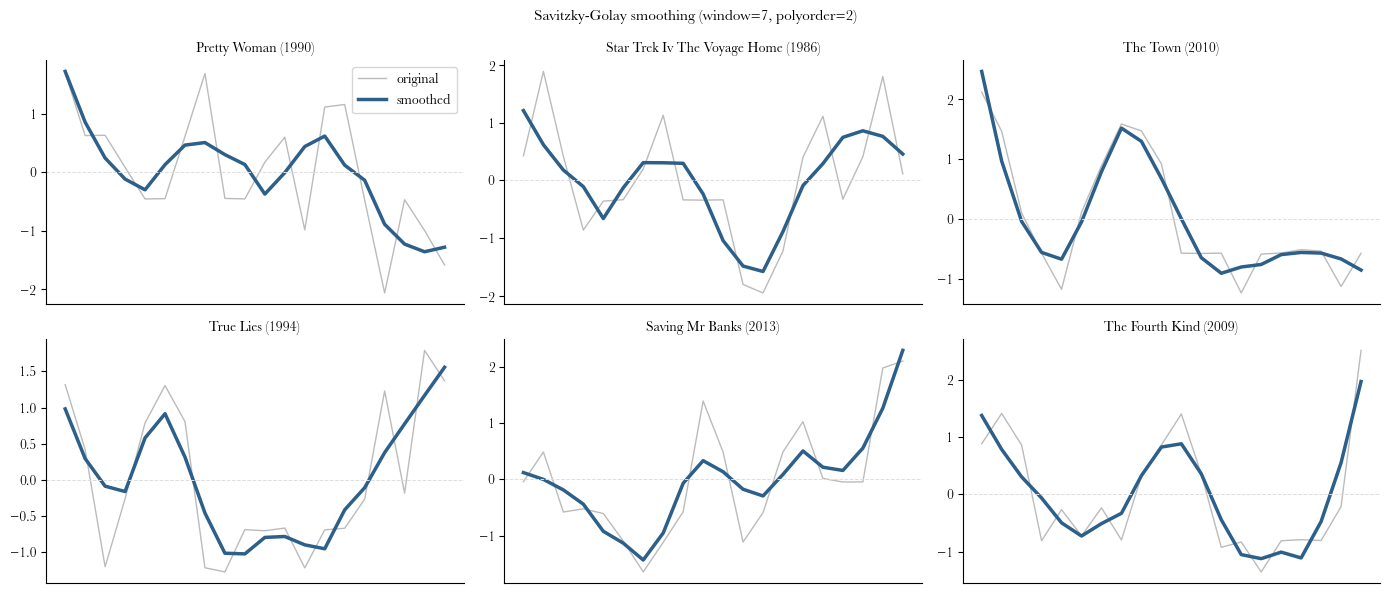

In [4]:
# Smoothing parameters
SMOOTH_WINDOW    = 7   # must be odd and < 20
SMOOTH_POLYORDER = 2

arc_matrix = df[ARC_COLS].values.astype(float)

arc_matrix_smooth = np.apply_along_axis(
    lambda arc: savgol_filter(arc, window_length=SMOOTH_WINDOW, polyorder=SMOOTH_POLYORDER),
    axis=1,
    arr=arc_matrix
)

print(f"Mean per-arc std before smoothing: {arc_matrix.std(axis=1).mean():.4f}")
print(f"Mean per-arc std after  smoothing: {arc_matrix_smooth.std(axis=1).mean():.4f}")

# Before and after comparison
rng2   = np.random.default_rng(seed=7)
sample = rng2.choice(len(df), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, idx in zip(axes.flatten(), sample):
    ax.plot(x_pos, arc_matrix[idx],        color="#BBBBBB", linewidth=1,   label="original")
    ax.plot(x_pos, arc_matrix_smooth[idx], color="#2C5F8A", linewidth=2.5, label="smoothed")
    ax.axhline(0, color="#DDDDDD", linewidth=0.7, linestyle="--")
    ax.set_title(f"{df.iloc[idx]['title']} ({int(df.iloc[idx]['year'])})", fontsize=10)
    ax.set_xticks([])
    ax.spines[["top","right"]].set_visible(False)
axes.flatten()[0].legend(fontsize=10)
fig.suptitle(f"Savitzky-Golay smoothing (window={SMOOTH_WINDOW}, polyorder={SMOOTH_POLYORDER})",
             fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}final_smoothing.png", dpi=150, bbox_inches="tight")
plt.show()

This is good. Really really good. It captures the gist of the thing without all the small details.

## Section 3: Arc space exploration
Before fitting archetypes, I want to examine the global structure of the arc space. PCA would reveal the dominant axes of variation; UMAP would show the overall topology.

Variance explained by first N principal components:
  PC1– 1: 23.0%
  PC1– 2: 41.6%
  PC1– 3: 57.9%
  PC1– 4: 71.8%
  PC1– 5: 84.6%
  PC1– 6: 92.9%
  PC1– 7: 97.0%
  PC1– 8: 98.5%
  PC1– 9: 99.0%
  PC1–10: 99.3%


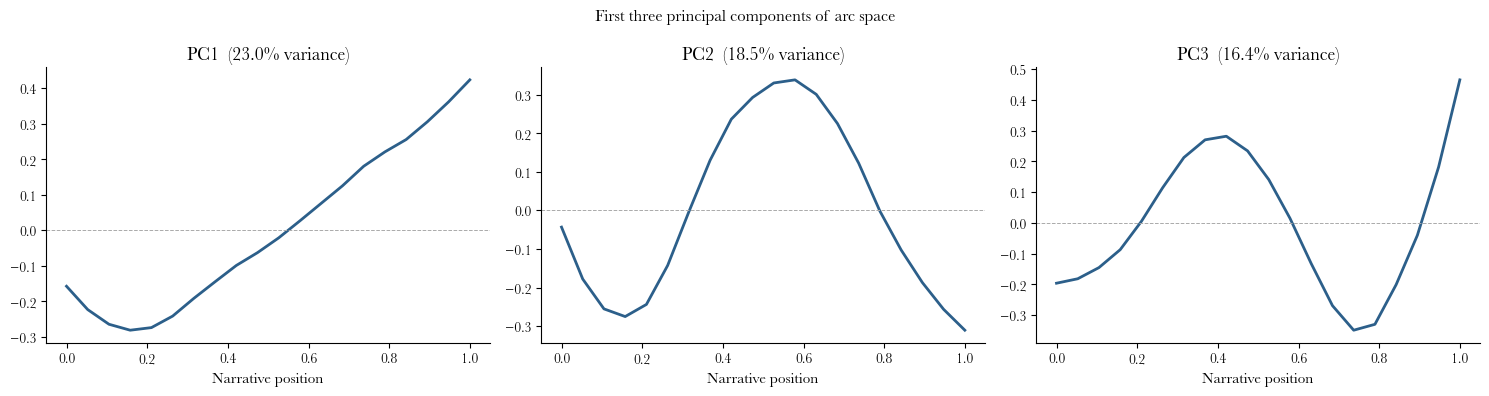

In [5]:
# PCA on the smoothed arcs
pca = PCA(n_components=10, random_state=42)
pca.fit(arc_matrix_smooth)

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
print("Variance explained by first N principal components:")
for n, v in enumerate(cumvar, 1):
    print(f"  PC1–{n:2d}: {v:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    axes[i].plot(x_pos, pca.components_[i], color="#2C5F8A", linewidth=2)
    axes[i].axhline(0, color="#AAAAAA", linewidth=0.7, linestyle="--")
    axes[i].set_title(f"PC{i+1}  ({pca.explained_variance_ratio_[i]*100:.1f}% variance)")
    axes[i].set_xlabel("Narrative position")
    axes[i].spines[["top","right"]].set_visible(False)
fig.suptitle("First three principal components of arc space", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}final_pca_modes.png", dpi=150, bbox_inches="tight")
plt.show()

Hmmm, not the most promising.


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


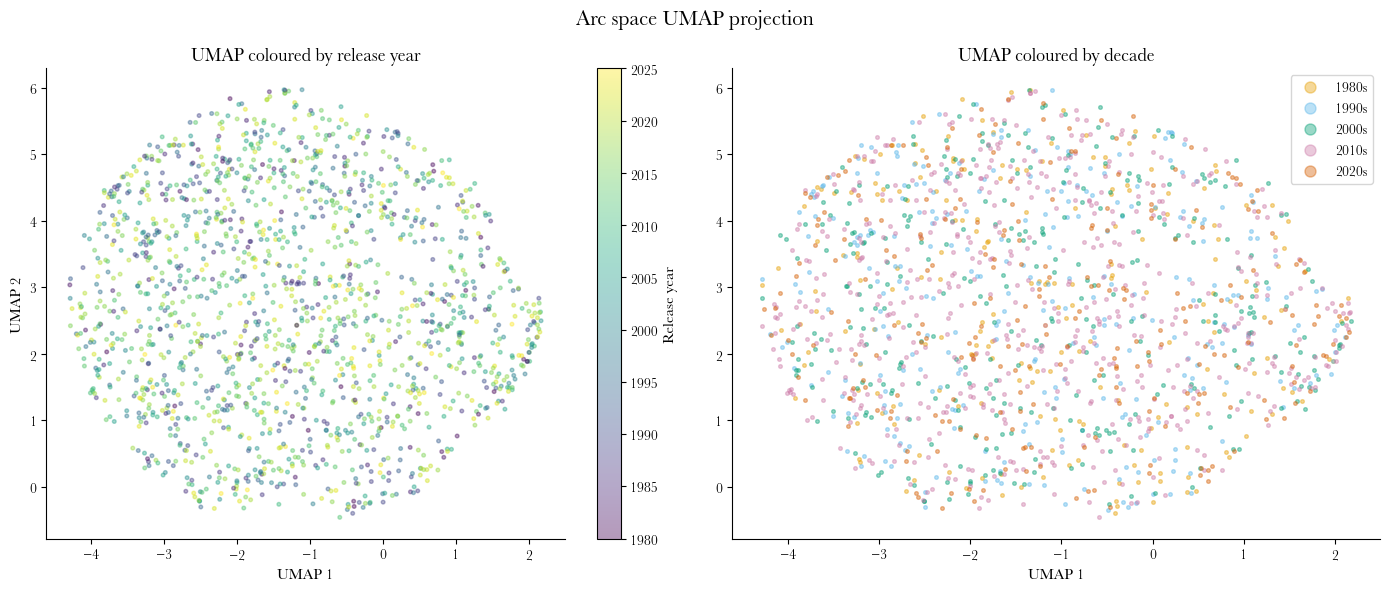

In [6]:
# UMAP projection
!{sys.executable} -m pip install --quiet umap-learn
import umap

decade_colours = {
    "1980s": "#E69F00", "1990s": "#56B4E9",
    "2000s": "#009E73", "2010s": "#CC79A7", "2020s": "#D55E00"
}

pca_50    = PCA(n_components=min(50, arc_matrix_smooth.shape[1]), random_state=42)
arc_pca50 = pca_50.fit_transform(arc_matrix_smooth)

reducer   = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                      metric="manhattan", random_state=42)
embedding = reducer.fit_transform(arc_pca50)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc = axes[0].scatter(embedding[:,0], embedding[:,1],
                     c=df["year"], cmap="viridis", alpha=0.4, s=7)
plt.colorbar(sc, ax=axes[0], label="Release year")
axes[0].set_title("UMAP coloured by release year")
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")
axes[0].spines[["top","right"]].set_visible(False)

for decade, colour in decade_colours.items():
    mask = df["decade"] == decade
    axes[1].scatter(embedding[mask,0], embedding[mask,1],
                    c=colour, alpha=0.4, s=7, label=decade)
axes[1].set_title("UMAP coloured by decade")
axes[1].set_xlabel("UMAP 1")
axes[1].legend(markerscale=3, fontsize=10)
axes[1].spines[["top","right"]].set_visible(False)

fig.suptitle(
    "Arc space UMAP projection",
    fontsize=15
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}final_umap.png", dpi=150, bbox_inches="tight")
plt.show()

The arc space forms a continuum, which means there are no natural discrete clusters.



print("Archetypal Analysis finds the extreme corners of this cloud rather than forcing")
print("artificial boundaries through the middle of blended data.")

The key finding that motivates Archetypal Analysis: the arc space is a **continuous cloud**
with no discrete islands — hard clustering imposes artificial boundaries on inherently
blended data. Archetypal Analysis instead finds the extreme corners of this cloud.

## Section 3b: Non-parametric cluster check

The UMAP above suggests a continuous cloud, not discrete islands. Before committing to Archetypal Analysis, we confirm this with two methods that **do not require specifying the number of clusters in advance**:

1. **HDBSCAN** — density-based; labels sparse regions as noise rather than forcing assignment. If arc space is truly continuous, HDBSCAN should return very few clusters (or one large cluster plus noise).
2. **Dirichlet Process Gaussian Mixture** — we allow up to 20 components and let the stick-breaking prior prune unused ones. The posterior decides how many components the data supports.

A negative result here — no clean discrete structure — is itself the justification for modelling arcs as *extremes of a continuum* (Archetypal Analysis) rather than as cluster centroids.


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
HDBSCAN (min_cluster_size=32):
  clusters found : 0
  noise points   : 1627  (100.0%)

Dirichlet Process GMM (max k = 20):
  effective components (weight > 1%): 10
  component weights (sorted):
     0.817  █████████████████████████████████████████████████
     0.012  
     0.012  
     0.011  
     0.011  
     0.011  
     0.011  
     0.011  
     0.011  
     0.010  
     0.010  
     0.010  
     0.009  
     0.009  
     0.009  
     0.008  
     0.007  
     0.007  
     0.007  
     0.006  


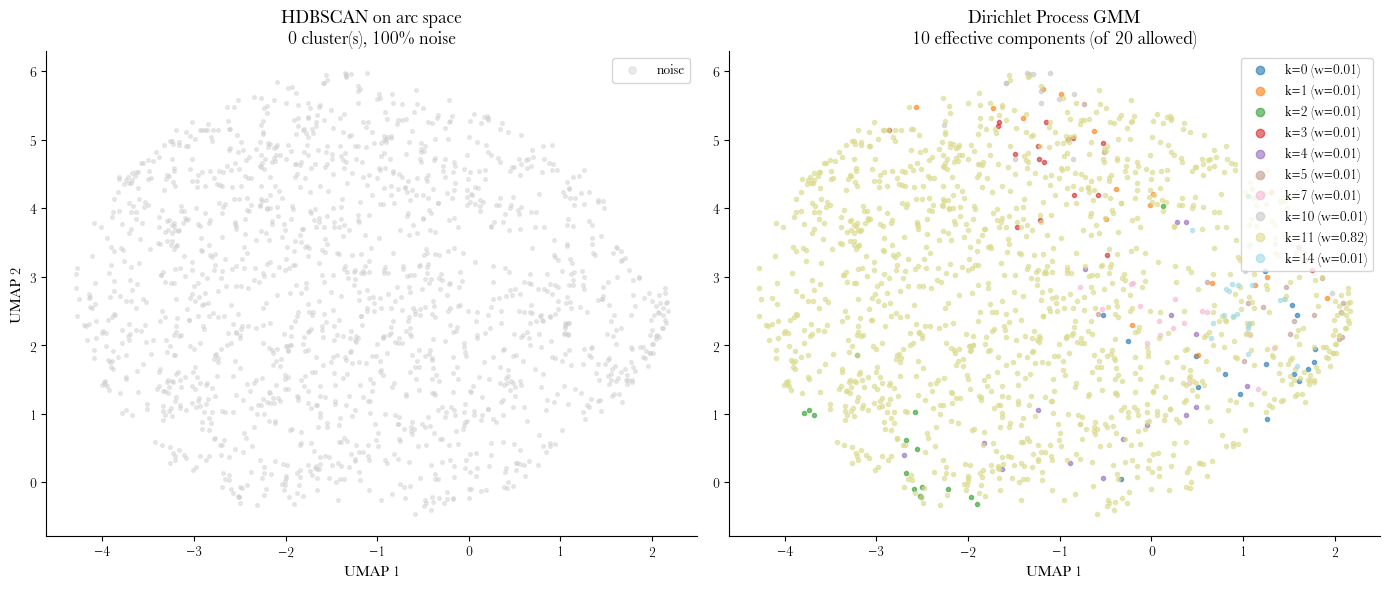

In [7]:
# Non-parametric cluster check with HDBSCAN + Dirichlet Process GMM
# Neither method requires pre-specifying k. Both run on the PCA-50 representation used for UMAP (arc_pca50) so results are directly comparable to the projection above
!{sys.executable} -m pip install --quiet hdbscan
import hdbscan
from sklearn.mixture import BayesianGaussianMixture

# HDBSCAN
# min_cluster_size ≈ 2% of corpus: any "genuine" sub-population should have at least this many films, otherwise it is noise rather than a narrative type
min_cs = max(20, int(0.02 * len(arc_pca50)))
hdb    = hdbscan.HDBSCAN(min_cluster_size=min_cs, metric="euclidean",
                         cluster_selection_method="eom")
hdb_labels = hdb.fit_predict(arc_pca50)

n_clusters_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise        = int((hdb_labels == -1).sum())
print(f"HDBSCAN (min_cluster_size={min_cs}):")
print(f"  clusters found : {n_clusters_hdb}")
print(f"  noise points   : {n_noise}  ({n_noise/len(hdb_labels)*100:.1f}%)")
if n_clusters_hdb > 0:
    import collections
    sizes = collections.Counter(l for l in hdb_labels if l != -1)
    print(f"  cluster sizes  : {dict(sizes)}")

# Dirichlet Process GMM
# Allow up to 20 components; the stick-breaking prior prunes unused ones
# Components with weight < 1% of corpus are treated as pruned
MAX_K   = 20
dp_gmm  = BayesianGaussianMixture(
    n_components=MAX_K,
    weight_concentration_prior_type="dirichlet_process",
    weight_concentration_prior=1.0 / MAX_K,
    covariance_type="full",
    max_iter=500,
    random_state=42,
).fit(arc_pca50)

effective = int((dp_gmm.weights_ > 0.01).sum())
print(f"\nDirichlet Process GMM (max k = {MAX_K}):")
print(f"  effective components (weight > 1%): {effective}")
print(f"  component weights (sorted):")
for w in sorted(dp_gmm.weights_, reverse=True):
    bar = "█" * int(w * 60)
    print(f"    {w:6.3f}  {bar}")

# Overlay HDBSCAN labels on the UMAP from the previous cell
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette = plt.cm.tab10(np.linspace(0, 1, max(n_clusters_hdb, 1)))
for lbl in sorted(set(hdb_labels)):
    mask = hdb_labels == lbl
    if lbl == -1:
        axes[0].scatter(embedding[mask,0], embedding[mask,1],
                        c="#CCCCCC", alpha=0.4, s=7, label="noise")
    else:
        axes[0].scatter(embedding[mask,0], embedding[mask,1],
                        c=[palette[lbl]], alpha=0.6, s=9, label=f"cluster {lbl}")
axes[0].set_title(f"HDBSCAN on arc space\n{n_clusters_hdb} cluster(s), {n_noise/len(hdb_labels)*100:.0f}% noise")
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")
axes[0].legend(markerscale=2, fontsize=10, loc="best")
axes[0].spines[["top","right"]].set_visible(False)

dp_labels = dp_gmm.predict(arc_pca50)
kept      = [i for i, w in enumerate(dp_gmm.weights_) if w > 0.01]
dp_palette = plt.cm.tab20(np.linspace(0, 1, len(kept)))
for j, k in enumerate(kept):
    mask = dp_labels == k
    axes[1].scatter(embedding[mask,0], embedding[mask,1],
                    c=[dp_palette[j]], alpha=0.6, s=9,
                    label=f"k={k} (w={dp_gmm.weights_[k]:.2f})")
axes[1].set_title(f"Dirichlet Process GMM\n{effective} effective components (of {MAX_K} allowed)")
axes[1].set_xlabel("UMAP 1")
axes[1].legend(markerscale=2, fontsize=10, loc="best")
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}final_nonparametric_check.png", dpi=150, bbox_inches="tight")
plt.show()


I can see clearly that arc space has no clean discrete structure. Both methods corroborate the continuum observed in the UMAP.

## Section 4: Archetypal analysis
**Archetypal Analysis** (Cutler & Breiman 1994) finds *k* extreme prototype shapes (the "archetypes") that sit at the boundary of the data cloud. Every film is then expressed as a convex mixture of these archetypes (weights sum to 1, all ≥ 0).

This is more faithful to the data than hard clustering because:
- Arc space is a continuum; most films blend multiple shapes
- Archetypes are the *purest* examples of each shape, not abstract centroids
- Mixture weights give a richer signal for the decade drift analysis

I use PCHA (Principal Convex Hull Analysis) implemented in `py_pcha`.

**Choosing k:** I sweep k=2..10 and look for the elbow in reconstruction error (RSS).
A sharp elbow marks where adding more archetypes stops explaining new variance.

In [8]:
from py_pcha import PCHA

k_range  = range(2, 11)
rss_list = []
var_list = []

print("Sweeping k — this takes a bit")
print(f"{'k':>3}  {'RSS':>10}  {'Var Expl':>10}")
print("-" * 28)
for k in k_range:
    np.random.seed(42)
    XC, S, C, SSE, varexpl = PCHA(arc_matrix_smooth.T, noc=k, delta=0.0)
    rss_list.append(SSE)
    var_list.append(varexpl)
    print(f"{k:>3}  {SSE:>10.4f}  {varexpl:>10.4f}")

Sweeping k — this takes a bit
  k         RSS    Var Expl
----------------------------
  2  12810.8452      0.3079
  3  10014.7911      0.4589
  4   8074.1342      0.5638
  5   6885.3860      0.6280
  6   5750.4633      0.6893
  7   5304.9400      0.7134
  8   4827.4455      0.7392
  9   4463.1117      0.7589
 10   3950.8634      0.7865


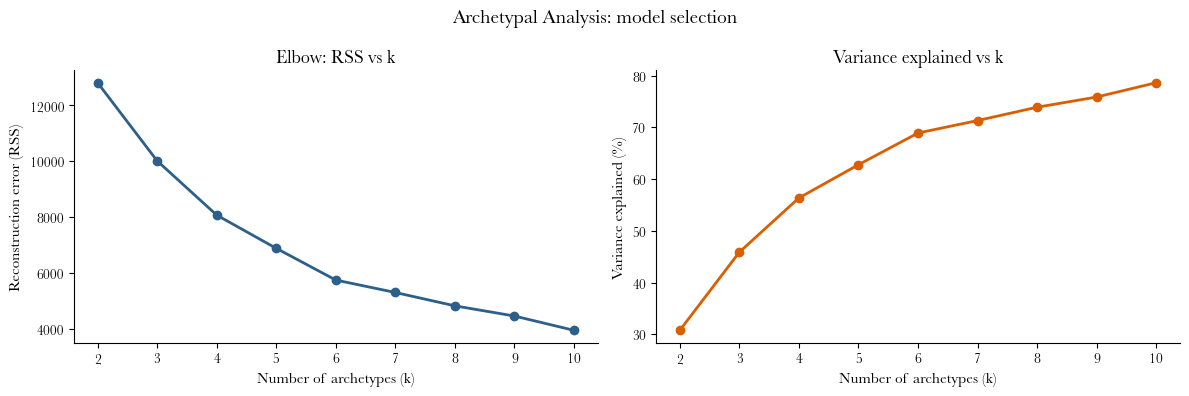

In [9]:
# Elbot plot here it comes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), rss_list, marker="o", color="#2C5F8A", linewidth=2)
axes[0].set_xlabel("Number of archetypes (k)")
axes[0].set_ylabel("Reconstruction error (RSS)")
axes[0].set_title("Elbow: RSS vs k")
axes[0].set_xticks(list(k_range))
axes[0].spines[["top","right"]].set_visible(False)

axes[1].plot(list(k_range), [v*100 for v in var_list], marker="o", color="#D95F02", linewidth=2)
axes[1].set_xlabel("Number of archetypes (k)")
axes[1].set_ylabel("Variance explained (%)")
axes[1].set_title("Variance explained vs k")
axes[1].set_xticks(list(k_range))
axes[1].spines[["top","right"]].set_visible(False)

fig.suptitle("Archetypal Analysis: model selection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}final_archetype_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

This tells me that I should probably pick 6.

In [10]:
# Fit final archetypal model
# Set N_ARCHETYPES based on the elbow above.
# Default 6 matches Reagan et al. (2016)
N_ARCHETYPES = 6

np.random.seed(42)
XC, S, C, SSE, varexpl = PCHA(arc_matrix_smooth.T, noc=N_ARCHETYPES, delta=0.0)

# py_pcha returns numpy matrices, convert to plain arrays to avoid shape issues
archetypes = np.asarray(XC).T        # (k × 20) — each row is one archetype arc shape
weights    = np.asarray(S).T          # (n_films × k) — each row sums to 1

# Store weights in df
weight_cols = [f"arch_{i}_weight" for i in range(N_ARCHETYPES)]
for i, col in enumerate(weight_cols):
    df[col] = weights[:, i]

# Dominant archetype, hard assignment for categorical analysis
df["dominant_archetype"] = weights.argmax(axis=1)

print(f"Fitted {N_ARCHETYPES} archetypes")
print(f"Variance explained: {varexpl*100:.1f}%")
print(f"Reconstruction RSS: {SSE:.4f}")
print("\nDominant archetype distribution:")
for i in range(N_ARCHETYPES):
    n   = (df["dominant_archetype"] == i).sum()
    pct = n / len(df) * 100
    avg = weights[:, i].mean()
    print(f"  Archetype {i+1}: {n:4d} films ({pct:.1f}%)  — mean weight {avg:.3f}")


Fitted 6 archetypes
Variance explained: 68.9%
Reconstruction RSS: 5750.4633

Dominant archetype distribution:
  Archetype 1:  199 films (12.2%)  — mean weight 0.147
  Archetype 2:  277 films (17.0%)  — mean weight 0.173
  Archetype 3:  332 films (20.4%)  — mean weight 0.185
  Archetype 4:  259 films (15.9%)  — mean weight 0.167
  Archetype 5:  252 films (15.5%)  — mean weight 0.150
  Archetype 6:  308 films (18.9%)  — mean weight 0.179


## Section 5: Archetype shapes
Each archetype is an extreme arc shape at the boundary of the corpus cloud.
The plot shows the archetype shape alongside the 10 films whose arc most closely
resembles a *pure* version of that archetype (highest mixture weight for it).

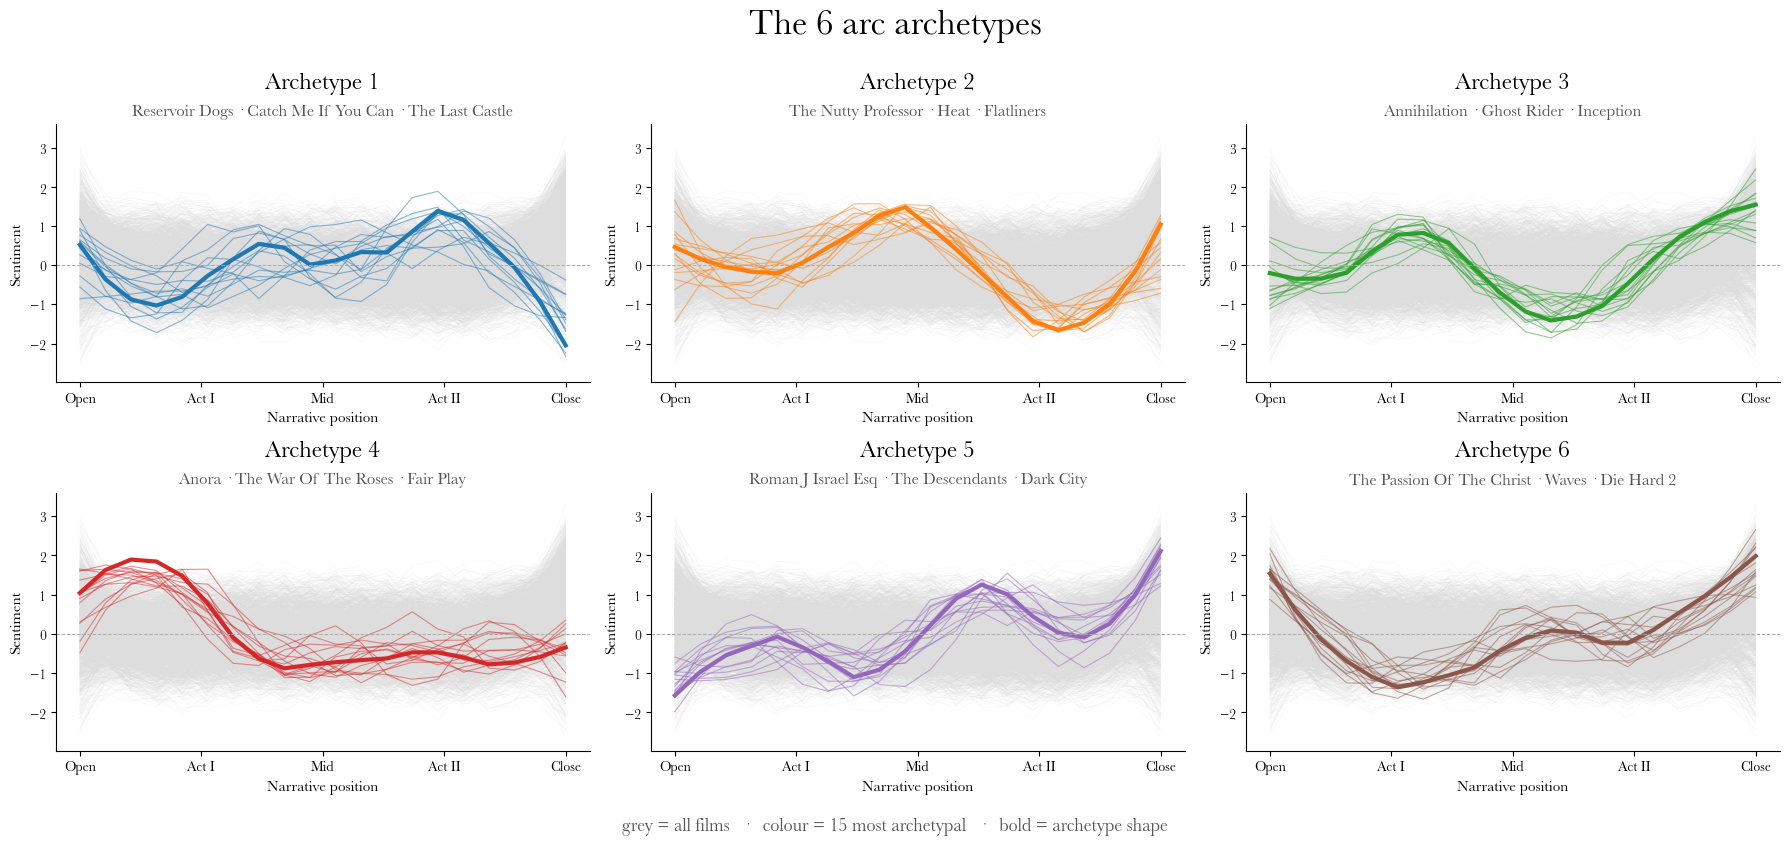


Archetype labels:
  Archetype 1: 'Oedipus'
  Archetype 2: 'Icarus'
  Archetype 3: 'Man in a Hole'
  Archetype 4: 'Tragedy'
  Archetype 5: 'Rags to Riches'
  Archetype 6: 'Cinderella'


In [11]:
# Archetype shape plots
palette = sns.color_palette("tab10", N_ARCHETYPES)
n_cols  = min(3, N_ARCHETYPES)
n_rows  = (N_ARCHETYPES + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

for i in range(N_ARCHETYPES):
    ax    = axes[i]
    color = palette[i]

    # Plot all films lightly, then highlight the 15 most archetypal
    for arc in arc_matrix_smooth:
        ax.plot(x_pos, arc, color="#DDDDDD", linewidth=0.3, alpha=0.3)

    top_idx = np.argsort(weights[:, i])[-15:][::-1]
    for idx in top_idx:
        ax.plot(x_pos, arc_matrix_smooth[idx], color=color, linewidth=0.8, alpha=0.5)

    # Archetype centre (weighted mean of top films)
    ax.plot(x_pos, archetypes[i], color=color, linewidth=3, label="archetype")
    ax.axhline(0, color="#AAAAAA", linewidth=0.7, linestyle="--")

    top3 = [df.iloc[j]["title"] for j in top_idx[:3]]
    ax.set_title(f"Archetype {i+1}", fontsize=17, fontweight="bold", pad=26)
    ax.text(0.5, 1.02, " · ".join(top3),
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=12, style="italic", color="#555555")
    ax.set_xlabel("Narrative position")
    ax.set_ylabel("Sentiment")
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(["Open", "Act I", "Mid", "Act II", "Close"], fontsize=10)
    ax.spines[["top","right"]].set_visible(False)

for j in range(N_ARCHETYPES, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"The {N_ARCHETYPES} arc archetypes",
             fontsize=25, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 1])
fig.text(0.5, -0.01,
         "grey = all films   ·   colour = 15 most archetypal   ·   bold = archetype shape",
         ha="center", va="top", fontsize=13, style="italic", color="#555555")
plt.savefig(f"{OUTPUT_DIR}final_archetypes.png", dpi=150, bbox_inches="tight")
plt.show()

# Arc names
archetype_names = {
    0: "Oedipus",
    1: "Icarus",
    2: "Man in a Hole",
    3: "Tragedy",
    4: "Rags to Riches",
    5: "Cinderella",
}
print("\nArchetype labels:")
for i in range(N_ARCHETYPES):
    print(f"  Archetype {i+1}: '{archetype_names[i]}'")

## Section 6: Most representative films
For each archetype, the films ranked by their mixture weight for that archetype, i.e. the films whose emotional shape most closely approximates a *pure* version of the type.

In [12]:
# Most representative films per archetype
for i in range(N_ARCHETYPES):
    top = df.nlargest(10, f"arch_{i}_weight")[["title", "year", "dominant_archetype", f"arch_{i}_weight"]]
    top = top.rename(columns={f"arch_{i}_weight": "weight"})
    label = archetype_names[i] or f"Archetype {i+1}"
    print(f"\n{label}")
    print(top.to_string(index=False))


Oedipus
                         title  year  dominant_archetype   weight
                Reservoir Dogs  1992                   0 1.000000
           Catch Me If You Can  2002                   0 0.836051
               The Last Castle  2001                   0 0.809603
                 Women Talking  2022                   0 0.738224
                  The Birdcage  1996                   0 0.736736
                  Last Holiday  2006                   0 0.728577
                 Live By Night  2016                   0 0.727974
       It Was Just An Accident  2025                   0 0.727463
The Hunger Games Catching Fire  2013                   0 0.724117
               Kill Bill Vol 1  2003                   0 0.723287

Icarus
                    title  year  dominant_archetype   weight
      The Nutty Professor  1996                   1 0.988455
                     Heat  1995                   1 0.928803
               Flatliners  2017                   1 0.882326
Where The Wil

## Section 7: Decade distribution
**Has the mix of story shapes shifted over Hollywood decades?**

Two complementary views:
1. **Mean archetype weight per decade**: continuous; how much each decade gravitates toward each extreme shape
2. **Dominant archetype distribution per decade**: categorical bar chart and chi-square test

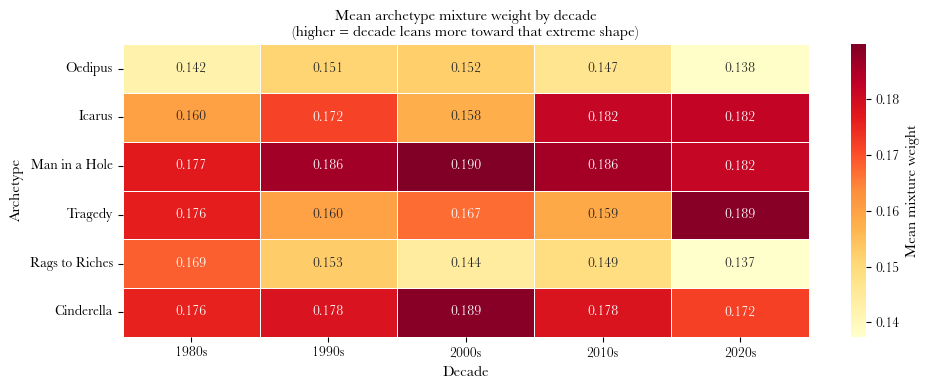

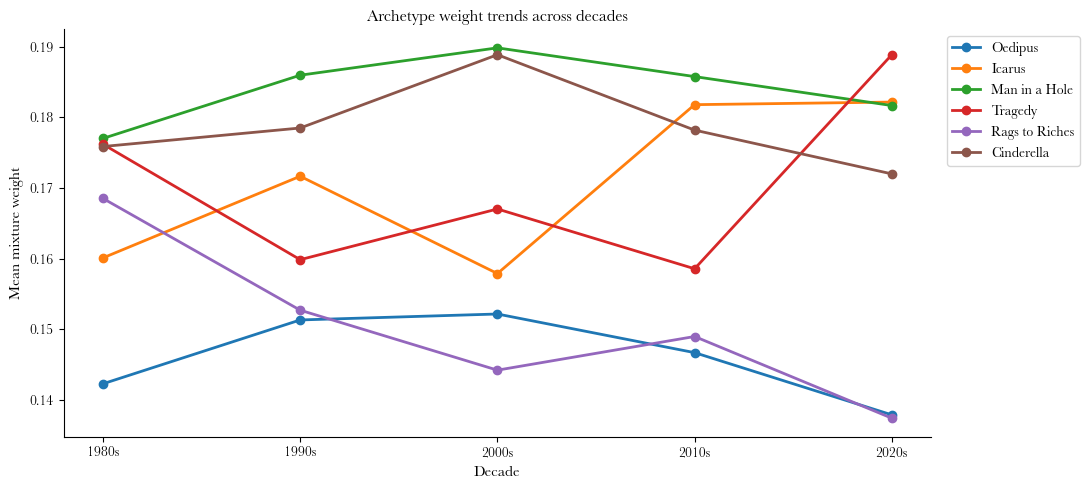

In [13]:
# Mean archetype weights per decade
decade_order = ["1980s", "1990s", "2000s", "2010s", "2020s"]
weight_by_decade = (
    df[df["decade"].isin(decade_order)]
    .groupby("decade")[weight_cols]
    .mean()
    .reindex(decade_order)
)
weight_by_decade.columns = [archetype_names[i] or f"Arch {i+1}" for i in range(N_ARCHETYPES)]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    weight_by_decade.T,
    annot=True, fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Mean mixture weight"}
)
ax.set_title("Mean archetype mixture weight by decade\n(higher = decade leans more toward that extreme shape)",
             fontsize=11)
ax.set_xlabel("Decade")
ax.set_ylabel("Archetype")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}final_weight_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Weight trends over time
fig, ax = plt.subplots(figsize=(11, 5))
for i in range(N_ARCHETYPES):
    label = archetype_names[i] or f"Archetype {i+1}"
    ax.plot(decade_order, weight_by_decade.iloc[:, i], marker="o", linewidth=2,
            color=palette[i], label=label)
ax.set_xlabel("Decade")
ax.set_ylabel("Mean mixture weight")
ax.set_title("Archetype weight trends across decades", fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}final_weight_trends.png", dpi=150, bbox_inches="tight")
plt.show()

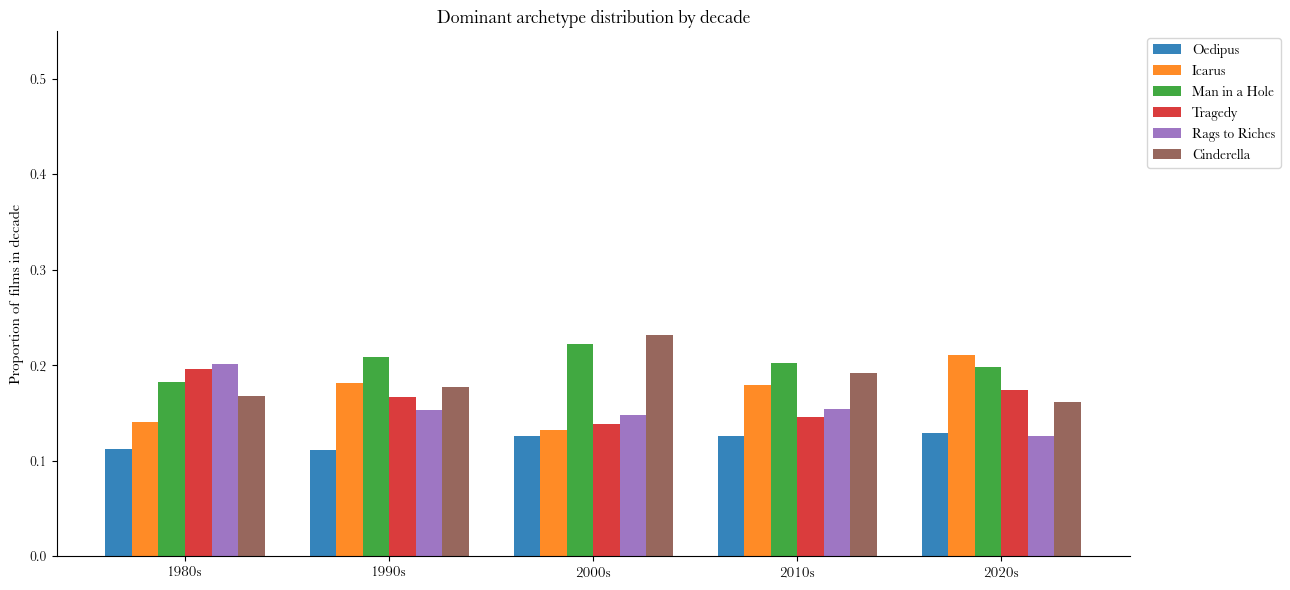

In [14]:
# Dominant archetype distribution per decade
contingency = pd.crosstab(df["dominant_archetype"], df["decade"])[decade_order]

# Normalise to proportions within each decade
prop = contingency.div(contingency.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(13, 6))
bar_width = 0.13
n_arch    = N_ARCHETYPES
x         = np.arange(len(decade_order))

for i in range(n_arch):
    label  = archetype_names[i] or f"Archetype {i+1}"
    offset = (i - n_arch / 2 + 0.5) * bar_width
    ax.bar(x + offset, prop.loc[i] if i in prop.index else [0]*len(decade_order),
           width=bar_width, color=palette[i], label=label, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(decade_order, fontsize=11)
ax.set_ylabel("Proportion of films in decade")
ax.set_ylim(0, 0.55)
ax.set_title("Dominant archetype distribution by decade", fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}final_decade_barchart.png", dpi=150, bbox_inches="tight")
plt.show()

Chi-square test: dominant archetype × decade
  χ² = 21.25,  df = 20,  p = 0.3828
No significant difference in archetype distribution across decades.


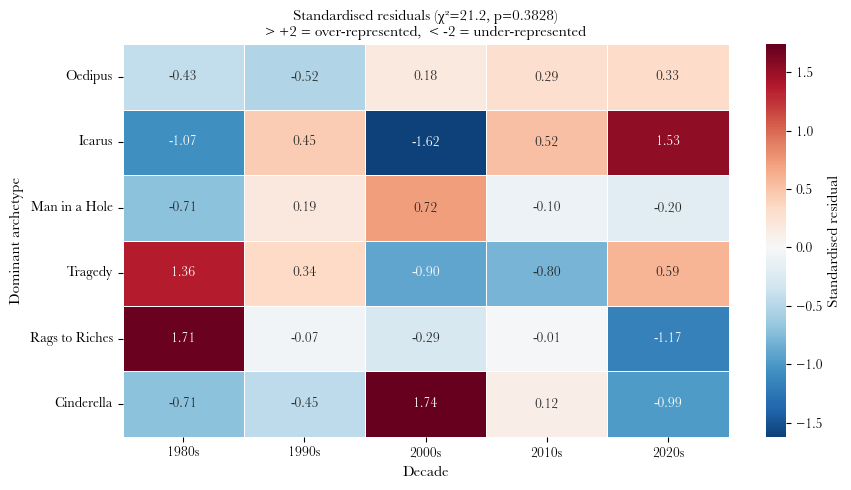

In [15]:
# Chi-square test: dominant archetype × decade
from scipy.stats import chi2_contingency

chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
print(f"Chi-square test: dominant archetype × decade")
print(f"  χ² = {chi2_stat:.2f},  df = {dof},  p = {p_val:.4f}")
if p_val < 0.05:
    print("Statistically significant: archetype distribution differs across decades.")
else:
    print("No significant difference in archetype distribution across decades.")

# Standardised residuals
residuals = (contingency - expected) / np.sqrt(expected)
residuals_df = pd.DataFrame(residuals, index=contingency.index,
                             columns=contingency.columns)
residuals_df.index = [archetype_names[i] or f"Archetype {i+1}" for i in residuals_df.index]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(residuals_df, annot=True, fmt=".2f", center=0,
            cmap="RdBu_r", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Standardised residual"})
ax.set_title(f"Standardised residuals (χ²={chi2_stat:.1f}, p={p_val:.4f})\n"
             "> +2 = over-represented,  < -2 = under-represented", fontsize=11)
ax.set_xlabel("Decade")
ax.set_ylabel("Dominant archetype")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}final_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 8: Genre distribution within archetypes
Genre is not an input to the model. Arc families were found purely from emotional shape. Any genre skew within an archetype is an emergent finding.

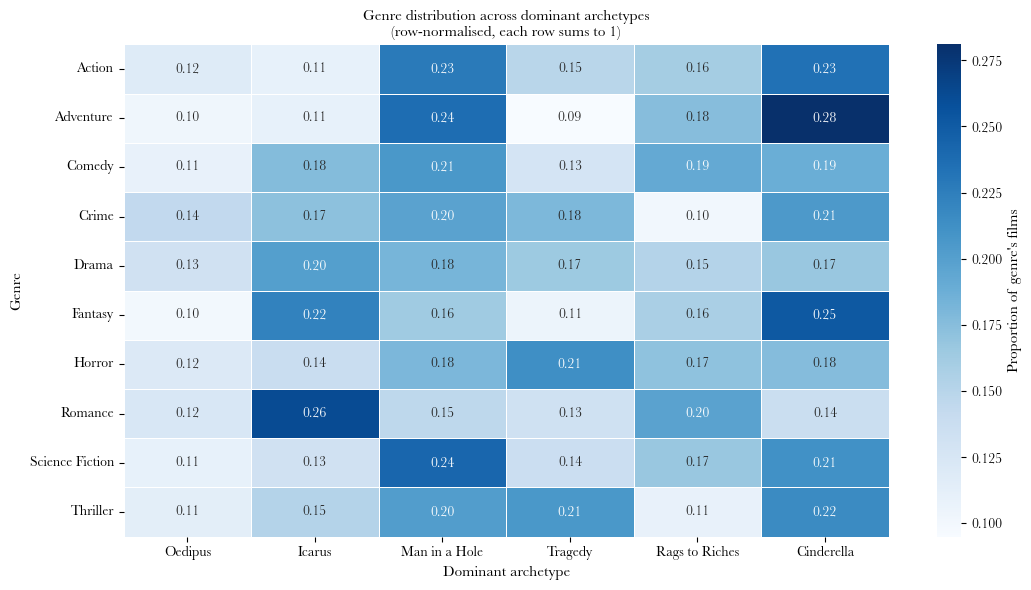

In [16]:
# Genre × archetype heatmap
df_exploded = (
    df.assign(genre=df["genre"].str.split("|"))
    .explode("genre")
    .reset_index(drop=True)   # explode duplicates the index, reset to avoid crosstab error
)
df_exploded["genre"] = df_exploded["genre"].str.strip()

top10_genres = df_exploded["genre"].value_counts().head(10).index.tolist()
df_top = df_exploded[df_exploded["genre"].isin(top10_genres)]

genre_arch = pd.crosstab(df_top["genre"], df_top["dominant_archetype"])
genre_arch.columns = [archetype_names[i] or f"Arch {i+1}" for i in genre_arch.columns]

# Row-normalise: proportion of each archetype within each genre
genre_arch_norm = genre_arch.div(genre_arch.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(genre_arch_norm, annot=True, fmt=".2f",
            cmap="Blues", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Proportion of genre's films"})
ax.set_title("Genre distribution across dominant archetypes\n(row-normalised, each row sums to 1)",
             fontsize=11)
ax.set_xlabel("Dominant archetype")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}final_genre_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 9: Export
All outputs written to `thesis-outputs/`. The primary downstream files are:
- `emotional_arcs_clustered.csv`: full corpus with archetype weights and dominant archetype
- `archetype_shapes.csv`: the k archetype arc shapes (fill in `arc_name` after visual inspection)
- `archetype_decade_weights.csv`: mean weights per decade (continuous view)
- `archetype_decade_counts.csv`: dominant archetype contingency table

In [18]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. full dataframe with archetype weights + dominant archetype
df.to_csv(f"{OUTPUT_DIR}emotional_arcs_clustered.csv", index=False)
print(f"Saved emotional_arcs_clustered.csv  ({len(df)} rows)")

# 2. archetype shapes
arch_rows = []
for i in range(N_ARCHETYPES):
    row = {
        "archetype_id": i + 1,
        "arc_name":     archetype_names[i],   # fill in manually
        "film_count":   int((df["dominant_archetype"] == i).sum()),
        "median_year":  df[df["dominant_archetype"] == i]["year"].median(),
    }
    for j, col in enumerate(ARC_COLS):
        row[col] = round(float(archetypes[i, j]), 6)
    arch_rows.append(row)

pd.DataFrame(arch_rows).to_csv(f"{OUTPUT_DIR}archetype_shapes.csv", index=False)
print(f"Saved archetype_shapes.csv  ({N_ARCHETYPES} archetypes)")

# 3. mean weights per decade
weight_by_decade.to_csv(f"{OUTPUT_DIR}archetype_decade_weights.csv")
print(f"Saved archetype_decade_weights.csv")

# 4. dominant archetype contingency table
contingency.to_csv(f"{OUTPUT_DIR}archetype_decade_counts.csv")
print(f"Saved archetype_decade_counts.csv")

print("\nAll exports complete.")
print("  arc_name column in archetype_shapes.csv is blank. I'll assign after inspecting Section 5.")

Saved emotional_arcs_clustered.csv  (1627 rows)
Saved archetype_shapes.csv  (6 archetypes)
Saved archetype_decade_weights.csv
Saved archetype_decade_counts.csv

All exports complete.
  arc_name column in archetype_shapes.csv is blank. I'll assign after inspecting Section 5.
